# Multiplayer: Parameter-Studie K (Kartenzahl)

Wie beeinflusst die Deckgroesse die Multiplayer-Fairness?

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))
import json

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16

In [3]:
from simulation import (
    TopTrumpsMultiplayerSimulation,
    TopTrumpsMultiplayerBalancing,
    evaluate_multiplayer_deck_detailed
)

In [4]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [5]:
RESULTS_DIR = Path('../results/multiplayer_param_study')
PLOTS_DIR = Path('../plots/multiplayer_param_study')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## Parameter

In [6]:
PLAYER_STRATEGIES = ['p4', 'p0', 'p0']  # 3 Spieler: 1E vs 2A
NUM_PLAYERS = len(PLAYER_STRATEGIES)

K_VALUES = [12, 18, 24, 30, 36]

L = 4
XL, XU = 1.0, 10.0
POP_SIZE = 50
N_GEN = 80
R_EVAL_FAST = 1000   # Simulations during optimization
R_EVAL_FINAL = 1500  # Simulations for validation

print(f'Spieler: {NUM_PLAYERS}, K-Werte: {K_VALUES}')

Spieler: 3, K-Werte: [12, 18, 24, 30, 36]


## Optimierung fuer verschiedene K

In [7]:
k_results = {}

for K in K_VALUES:
    print(f'\n=== K = {K} ({K // NUM_PLAYERS} Karten/Spieler) ===')
    
    np.random.seed(SEED)
    random.seed(SEED)
    
    sim = TopTrumpsMultiplayerSimulation(
        num_cards=K, num_categories=L, player_strategies=PLAYER_STRATEGIES
    )
    
    problem = TopTrumpsMultiplayerBalancing(
        sim_instance=sim, n_simulations=R_EVAL_FAST, xl=XL, xu=XU
    )
    
    algorithm = NSGA2(
        pop_size=POP_SIZE, sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20), eliminate_duplicates=True
    )
    
    start = time.time()
    res = minimize(problem, algorithm, get_termination('n_gen', N_GEN), seed=SEED, verbose=False)
    opt_time = time.time() - start
    print(f'  Optimierung: {opt_time:.1f}s, {len(res.F)} Loesungen')
    
    validated = [evaluate_multiplayer_deck_detailed(sim, x, R=R_EVAL_FINAL) for x in res.X]
    validated_df = pd.DataFrame(validated)
    
    # Non-Dominated Sorting after validation
    F_val = np.column_stack([-validated_df['focus_expert_win_rate'].values, -validated_df['trick_changes'].values])
    nds = NonDominatedSorting()
    fronts = nds.do(F_val)
    non_dominated_idx = fronts[0]
    n_before = len(validated_df)
    validated_df = validated_df.iloc[non_dominated_idx].reset_index(drop=True)
    F_val = F_val[non_dominated_idx]
    
    hv = HV(ref_point=np.array([0.0, 0.0]))(F_val)
    
    k_results[K] = {
        'K': K, 'cards_per_player': K // NUM_PLAYERS,
        'validated_df': validated_df, 'hypervolume': hv, 'optimization_time': opt_time,
        'stats': {
            'focus_expert_win_rate_mean': validated_df['focus_expert_win_rate'].mean(),
            'focus_expert_win_rate_min': validated_df['focus_expert_win_rate'].min(),
            'focus_expert_win_rate_max': validated_df['focus_expert_win_rate'].max(),
            'trick_changes_mean': validated_df['trick_changes'].mean(),
            'trick_changes_min': validated_df['trick_changes'].min(),
            'trick_changes_max': validated_df['trick_changes'].max(),
            'tie_rate_mean': validated_df['tie_rate'].mean(),
            'n_solutions': len(validated_df)
        }
    }
    print(f'  NDS: {n_before} -> {len(validated_df)}, HV: {hv:.4f}, Focus E WR: {validated_df["focus_expert_win_rate"].mean():.1%}')

print('\nParameter-Studie abgeschlossen!')


=== K = 12 (4 Karten/Spieler) ===


  Optimierung: 38.3s, 21 Loesungen


  NDS: 21 -> 11, HV: 1.4542, Focus E WR: 54.1%

=== K = 18 (6 Karten/Spieler) ===


  Optimierung: 60.8s, 16 Loesungen


  NDS: 16 -> 7, HV: 2.0351, Focus E WR: 56.7%

=== K = 24 (8 Karten/Spieler) ===


...

  NDS: 13 -> 5, HV: 2.5361, Focus E WR: 55.2%

=== K = 30 (10 Karten/Spieler) ===


  Optimierung: 115.3s, 14 Loesungen


  NDS: 14 -> 3, HV: 3.2515, Focus E WR: 60.0%

=== K = 36 (12 Karten/Spieler) ===


  Optimierung: 150.9s, 16 Loesungen


  NDS: 16 -> 6, HV: 3.8464, Focus E WR: 62.0%

Parameter-Studie abgeschlossen!


## Ergebnis-Tabelle

In [8]:
summary = [{'K': K, 'Cards/Player': r['cards_per_player'],
            'Focus E WR': f"{r['stats']['focus_expert_win_rate_mean']:.1%}",
            'Trick Ch.': f"{r['stats']['trick_changes_mean']:.2f}",
            'Tie Rate': f"{r['stats']['tie_rate_mean']:.1%}",
            'HV': f"{r['hypervolume']:.3f}"} for K, r in k_results.items()]
pd.DataFrame(summary)

,K,Cards/Player,Focus E WR,Trick Ch.,Tie Rate,HV
0,12,4,54.1%,2.29,21.4%,1.454
1,18,6,56.7%,3.34,17.8%,2.035
2,24,8,55.2%,4.36,22.6%,2.536
3,30,10,60.0%,4.95,12.4%,3.251
4,36,12,62.0%,5.65,11.1%,3.846


## Pareto-Fronts Plot

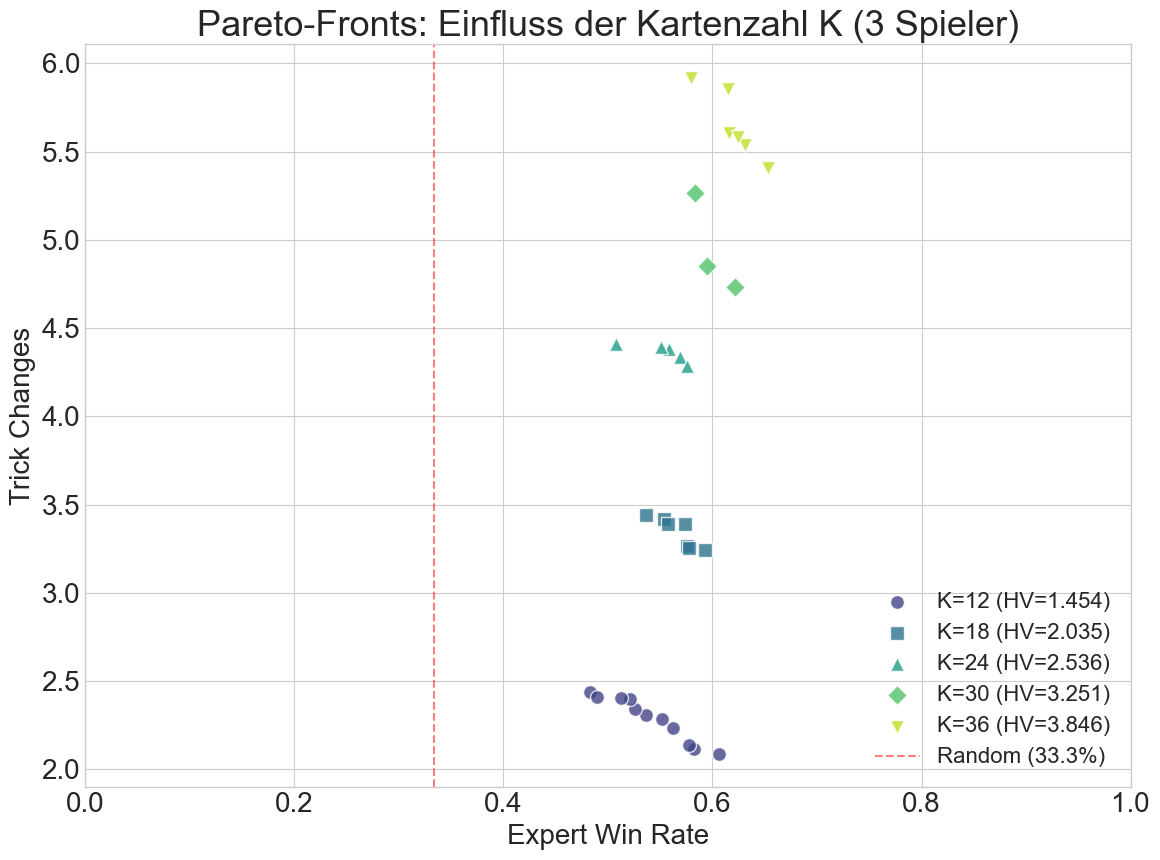

In [9]:
fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(K_VALUES)))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X']

for i, (K, r) in enumerate(k_results.items()):
    df = r['validated_df']
    ax.scatter(df['focus_expert_win_rate'], df['trick_changes'], c=[colors[i]], marker=markers[i % len(markers)],
               s=100, alpha=0.8, edgecolors='white', label=f'K={K} (HV={r["hypervolume"]:.3f})')

ax.axvline(1/NUM_PLAYERS, color='red', linestyle='--', alpha=0.5, label=f'Random ({1/NUM_PLAYERS:.1%})')
ax.set_xlabel('Expert Win Rate')
ax.set_ylabel('Trick Changes')
ax.set_title(f'Pareto-Fronts: Einfluss der Kartenzahl K ({NUM_PLAYERS} Spieler)')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'pareto_fronts_K.svg', format='svg')
plt.show()

## Metriken vs K

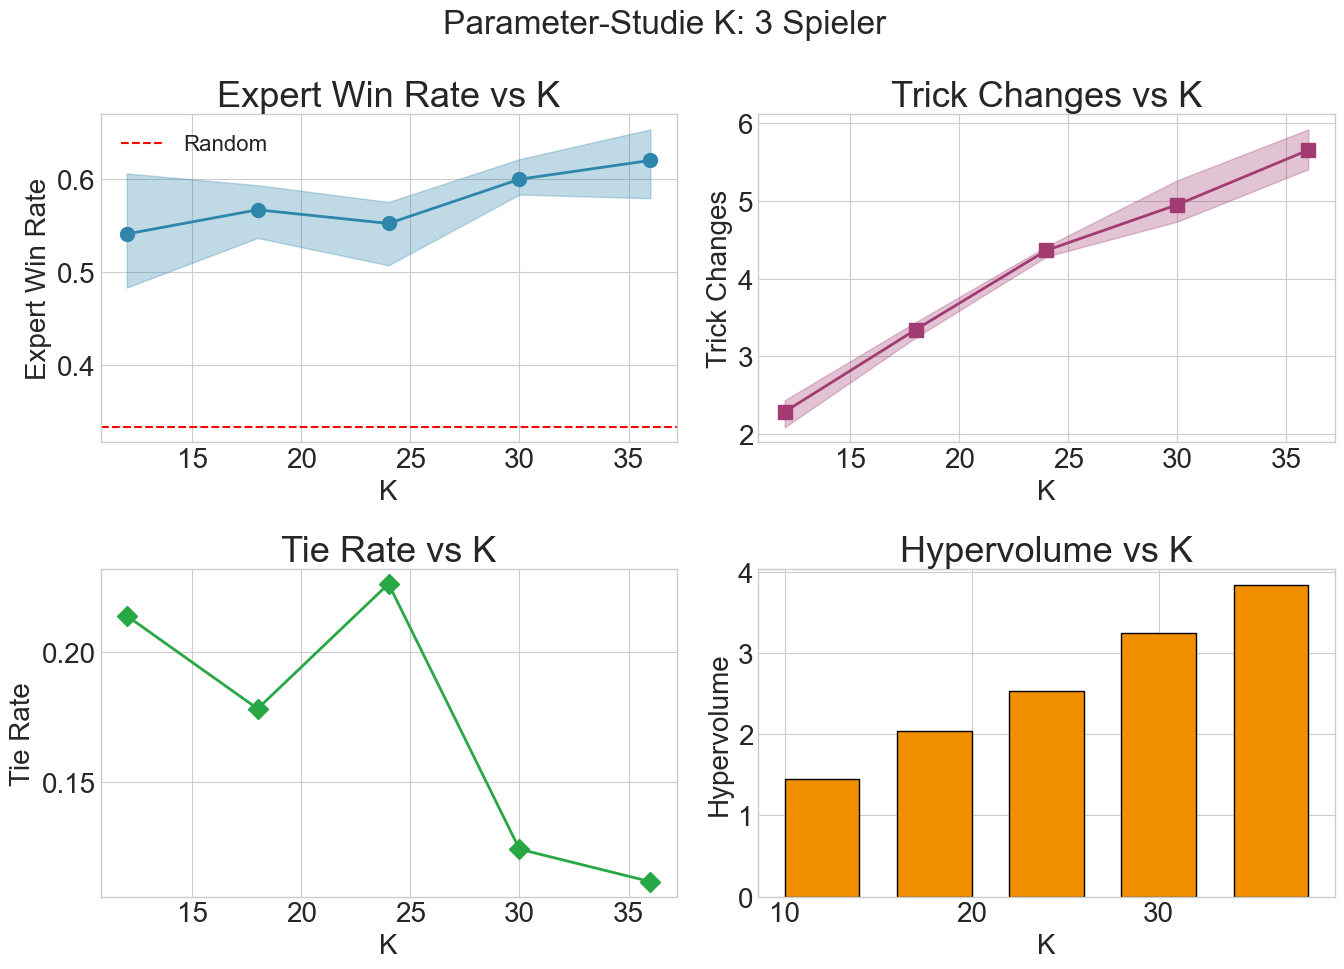

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
K_list = list(k_results.keys())

# Focus Expert Win Rate
wr_means = [k_results[K]['stats']['focus_expert_win_rate_mean'] for K in K_list]
wr_mins = [k_results[K]['stats']['focus_expert_win_rate_min'] for K in K_list]
wr_maxs = [k_results[K]['stats']['focus_expert_win_rate_max'] for K in K_list]
axes[0,0].fill_between(K_list, wr_mins, wr_maxs, alpha=0.3, color='#2E86AB')
axes[0,0].plot(K_list, wr_means, 'o-', color='#2E86AB', linewidth=2, markersize=10)
axes[0,0].axhline(1/NUM_PLAYERS, color='red', linestyle='--', label='Random')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Expert Win Rate')
axes[0,0].set_title('Expert Win Rate vs K'); axes[0,0].legend()

# Trick Changes
tc_means = [k_results[K]['stats']['trick_changes_mean'] for K in K_list]
tc_mins = [k_results[K]['stats']['trick_changes_min'] for K in K_list]
tc_maxs = [k_results[K]['stats']['trick_changes_max'] for K in K_list]
axes[0,1].fill_between(K_list, tc_mins, tc_maxs, alpha=0.3, color='#A23B72')
axes[0,1].plot(K_list, tc_means, 's-', color='#A23B72', linewidth=2, markersize=10)
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Trick Changes')
axes[0,1].set_title('Trick Changes vs K')

# Tie Rate
ties = [k_results[K]['stats']['tie_rate_mean'] for K in K_list]
axes[1,0].plot(K_list, ties, 'D-', color='#28A745', linewidth=2, markersize=10)
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('Tie Rate')
axes[1,0].set_title('Tie Rate vs K')

# Hypervolume
hvs = [k_results[K]['hypervolume'] for K in K_list]
axes[1,1].bar(K_list, hvs, color='#F18F01', edgecolor='black', width=4)
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('Hypervolume')
axes[1,1].set_title('Hypervolume vs K')

plt.suptitle(f'Parameter-Studie K: {NUM_PLAYERS} Spieler')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'metrics_vs_K.svg', format='svg')
plt.show()

## Korrelationsanalyse

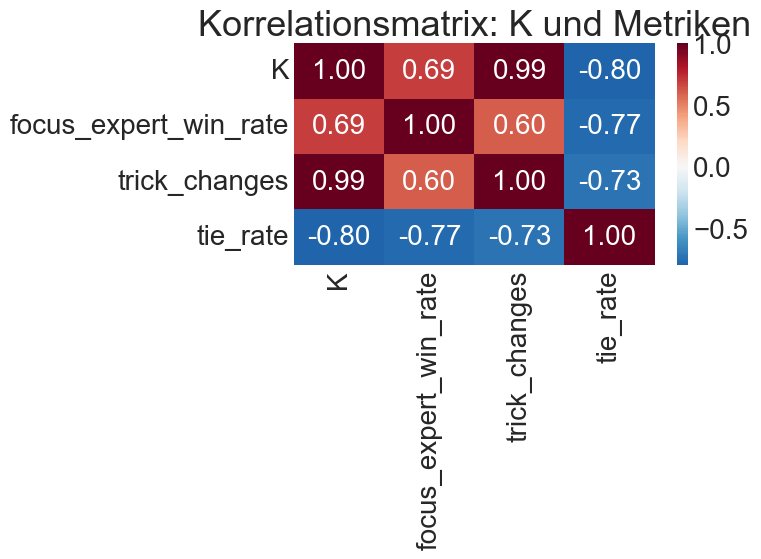


Correlations with K:
  K vs focus_expert_win_rate: 0.686
  K vs trick_changes: 0.988
  K vs tie_rate: -0.799


In [11]:
corr_data = []
for K, r in k_results.items():
    for _, row in r['validated_df'].iterrows():
        corr_data.append({'K': K, 'focus_expert_win_rate': row['focus_expert_win_rate'],
                          'trick_changes': row['trick_changes'], 'tie_rate': row['tie_rate']})
corr_df = pd.DataFrame(corr_data)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdBu_r', center=0, ax=ax, fmt='.2f')
ax.set_title('Korrelationsmatrix: K und Metriken')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_matrix.svg', format='svg')
plt.show()

print('\nCorrelations with K:')
for col in ['focus_expert_win_rate', 'trick_changes', 'tie_rate']:
    print(f"  K vs {col}: {corr_df['K'].corr(corr_df[col]):.3f}")

## Ergebnisse speichern

In [12]:
def convert_to_native(obj):
    """Convert numpy types to native Python types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [convert_to_native(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

export = {str(K): convert_to_native({'K': K, 'hypervolume': r['hypervolume'], 'stats': r['stats']}) for K, r in k_results.items()}
with open(RESULTS_DIR / 'parameter_study_K.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Results saved to', RESULTS_DIR)

Results saved to results/multiplayer_param_study


## Fazit

In [13]:
print('=== FAZIT ===')
best_hv = max(k_results.items(), key=lambda x: x[1]['hypervolume'])
print(f'Bester Hypervolume: K={best_hv[0]} (HV={best_hv[1]["hypervolume"]:.3f})')

k_wr_corr = corr_df['K'].corr(corr_df['focus_expert_win_rate'])
k_tc_corr = corr_df['K'].corr(corr_df['trick_changes'])
print(f'\nTrends:')
print(f'  Mehr Karten -> {"HOEHERE" if k_wr_corr > 0 else "NIEDRIGERE"} Expert Win Rate (r={k_wr_corr:.2f})')
print(f'  Mehr Karten -> {"MEHR" if k_tc_corr > 0 else "WENIGER"} Trick Changes (r={k_tc_corr:.2f})')

=== FAZIT ===
Bester Hypervolume: K=36 (HV=3.846)

Trends:
  Mehr Karten -> HOEHERE Expert Win Rate (r=0.69)
  Mehr Karten -> MEHR Trick Changes (r=0.99)
